Setup + data load

In [3]:
import pandas as pd   
import numpy as np         
import matplotlib.pyplot as plt 
import seaborn as sns 
from sqlalchemy import create_engine 

In [6]:
# Plot style — clean aur readable
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10,5)


In [4]:
# Connection (apna server/database naam daalo)
engine = create_engine(
    "mssql://DESKTOP-GVEVCJJ/Olist_Raw_Data"
        "?driver=ODBC+DRIVER+17+FOR+SQL+SERVER"
     "&trusted_connection=yes"
)

In [5]:
# Star schema load karo
fact_orders = pd.read_sql("select * from fact_orders", engine)
fact_order_items = pd.read_sql("select * from fact_order_items", engine)
dim_date = pd.read_sql("select * from dim_date", engine)
dim_product = pd.read_sql("select * from dim_product", engine)
dim_customer = pd.read_sql("select * from dim_customer", engine)

In [46]:
# Quick sanity check — jaisa hum SQL mein bhi karte the
print("fact_orders:", fact_orders.shape)
print("fact_order_items:", fact_order_items.shape)
print("dim_date:", dim_date.shape)
print("dim_product:", dim_product.shape)
print("dim_customer:", dim_customer.shape)

fact_orders: (99441, 15)
fact_order_items: (112650, 8)
dim_date: (1097, 9)
dim_product: (32952, 8)
dim_customer: (96097, 4)


Revenue & Orders trend over time


In [16]:
# Orders ko dim_date se join karo, purchase month nikaalne ke liye
orders_with_date = fact_orders.merge(
    dim_date[['date_key', 'year', 'month', 'month_name']],
    left_on='purchase_date_key', right_on='date_key', how='left'
)

In [19]:
# Monthly aggregation
monthly = orders_with_date.groupby(['year', 'month']).agg(
    total_revenue=('order_total_value', 'sum'),
    order_count=('order_id', 'count')
).reset_index()

In [20]:
# Year-month label banate hain sorting/plotting ke liye
monthly['year_month'] = pd.to_datetime(monthly[['year', 'month']].assign(day=1))
monthly = monthly.sort_values('year_month')

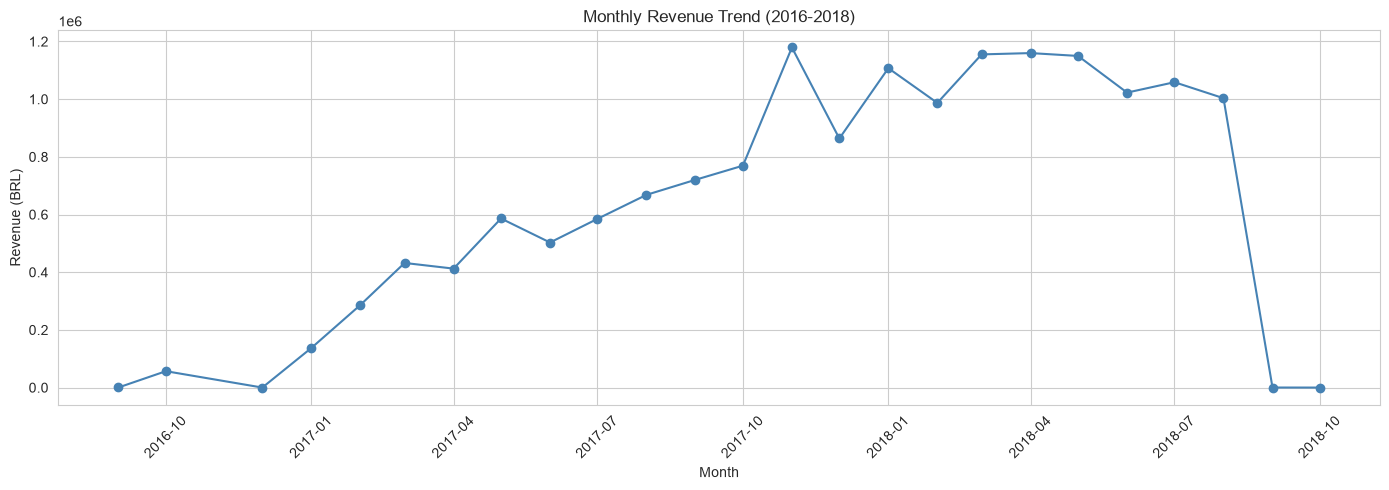

In [22]:
# Plot 1: Revenue trend
fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.plot(monthly['year_month'], monthly['total_revenue'], marker='o', color='steelblue')
ax1.set_title('Monthly Revenue Trend (2016-2018)')
ax1.set_ylabel('Revenue (BRL)')
ax1.set_xlabel('Month')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

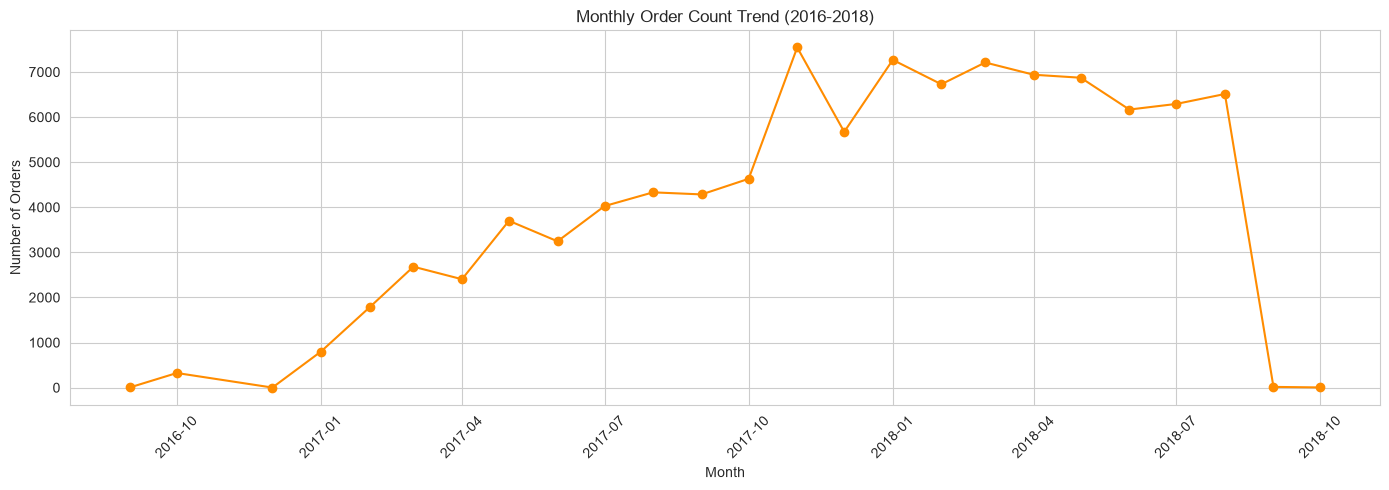

In [24]:
# Plot 2: Order count trend
fig, ax2 = plt.subplots(figsize=(14, 5))
ax2.plot(monthly['year_month'], monthly['order_count'], marker='o', color='darkorange')
ax2.set_title('Monthly Order Count Trend (2016-2018)')
ax2.set_ylabel('Number of Orders')
ax2.set_xlabel('Month')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [26]:
print(monthly[['year_month', 'order_count', 'total_revenue']].to_string(index=False))

year_month  order_count  total_revenue
2016-09-01            4         354.75
2016-10-01          324       56808.84
2016-12-01            1          19.62
2017-01-01          800      137188.49
2017-02-01         1780      286280.62
2017-03-01         2682      432048.59
2017-04-01         2404      412422.24
2017-05-01         3700      586190.95
2017-06-01         3245      502963.04
2017-07-01         4026      584971.62
2017-08-01         4331      668204.60
2017-09-01         4285      720398.91
2017-10-01         4631      769312.37
2017-11-01         7544     1179143.77
2017-12-01         5673      863547.23
2018-01-01         7269     1107301.89
2018-02-01         6728      986908.96
2018-03-01         7211     1155126.82
2018-04-01         6939     1159698.04
2018-05-01         6873     1149781.82
2018-06-01         6167     1022677.11
2018-07-01         6292     1058728.03
2018-08-01         6512     1003308.47
2018-09-01           16         166.46
2018-10-01            4  

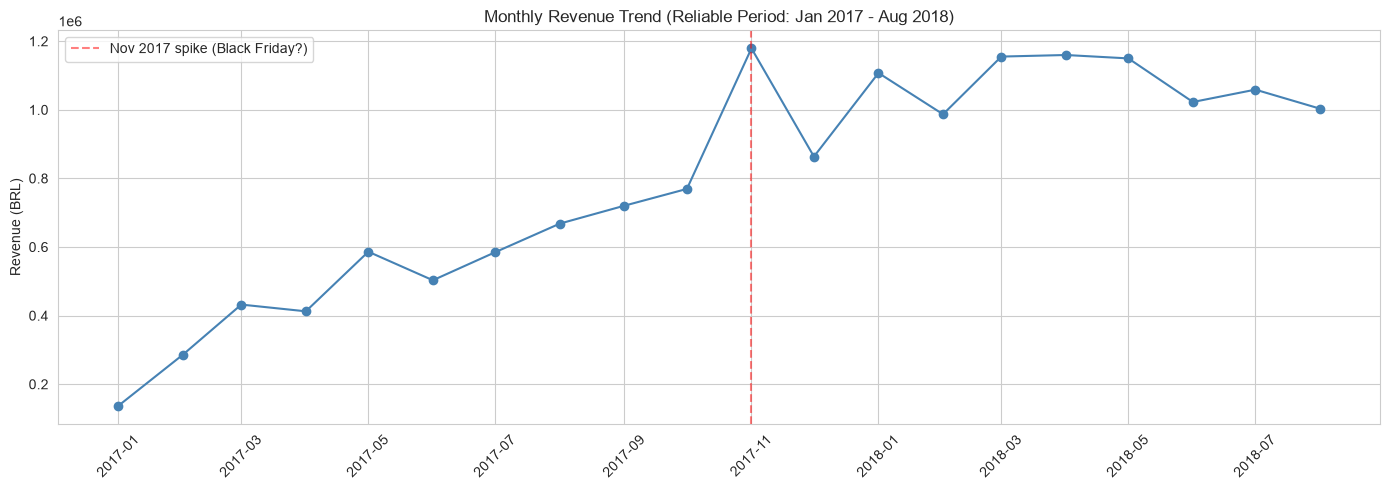

In [28]:
# Trim monthly 
monthly_trimmed = monthly[
    (monthly['year_month'] >= '2017-01-01') &
    (monthly['year_month'] <= '2018-08-01')
].copy()

fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.plot(monthly_trimmed['year_month'], monthly_trimmed['total_revenue'], marker='o', color='steelblue')
ax1.axvline(pd.Timestamp('2017-11-01'), color='red', linestyle='--', alpha=0.5, label='Nov 2017 spike (Black Friday?)')
ax1.set_title('Monthly Revenue Trend (Reliable Period: Jan 2017 - Aug 2018)')
ax1.set_ylabel('Revenue (BRL)')
ax1.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [30]:
# MoM growth rate on trimmed data 
monthly_trimmed['revenue_mom_pct'] = monthly_trimmed['total_revenue'].pct_change() * 100
print(monthly_trimmed[['year_month', 'order_count', 'total_revenue', 'revenue_mom_pct']].to_string(index=False))

year_month  order_count  total_revenue  revenue_mom_pct
2017-01-01          800      137188.49              NaN
2017-02-01         1780      286280.62       108.676850
2017-03-01         2682      432048.59        50.917862
2017-04-01         2404      412422.24        -4.542626
2017-05-01         3700      586190.95        42.133690
2017-06-01         3245      502963.04       -14.198089
2017-07-01         4026      584971.62        16.305091
2017-08-01         4331      668204.60        14.228550
2017-09-01         4285      720398.91         7.811127
2017-10-01         4631      769312.37         6.789774
2017-11-01         7544     1179143.77        53.272431
2017-12-01         5673      863547.23       -26.764891
2018-01-01         7269     1107301.89        28.227137
2018-02-01         6728      986908.96       -10.872638
2018-03-01         7211     1155126.82        17.044922
2018-04-01         6939     1159698.04         0.395733
2018-05-01         6873     1149781.82        -0

In [32]:
# for confirm "BlackFriday spike hypothesis"
nov_2017_daily = orders_with_date[
    (orders_with_date['year'] == 2017) & (orders_with_date['month'] == 11)
].merge(dim_date[['date_key', 'full_date']], left_on='purchase_date_key', right_on='date_key')

daily_orders = nov_2017_daily.groupby('full_date').size().reset_index(name='order_count')
daily_orders = daily_orders.sort_values('order_count', ascending=False)
print(daily_orders.head(10))

     full_date  order_count
23  2017-11-24         1176
24  2017-11-25          499
26  2017-11-27          403
25  2017-11-26          391
27  2017-11-28          380
28  2017-11-29          323
22  2017-11-23          283
29  2017-11-30          267
19  2017-11-20          230
20  2017-11-21          228


Order Value (AOV) Distribution

In [40]:
aov_data = fact_orders[fact_orders['order_total_value'] > 0]['order_total_value']
print(f"Count: {len(aov_data)}")
print(f"Mean: {aov_data.mean():.2f}")
print(f"Median: {aov_data.median():.2f}")
print(f"Std Dev: {aov_data.std():.2f}")
print(f"Min: {aov_data.min():.2f}, Max: {aov_data.max():.2f}")
print(f"25th percentile: {aov_data.quantile(0.25):.2f}")
print(f"75th percentile: {aov_data.quantile(0.75):.2f}")
print(f"95th percentile: {aov_data.quantile(0.95):.2f}")
print(f"99th percentile: {aov_data.quantile(0.99):.2f}")

Count: 98666
Mean: 160.58
Median: 105.29
Std Dev: 220.47
Min: 9.59, Max: 13664.08
25th percentile: 61.98
75th percentile: 176.87
95th percentile: 450.53
99th percentile: 1063.32


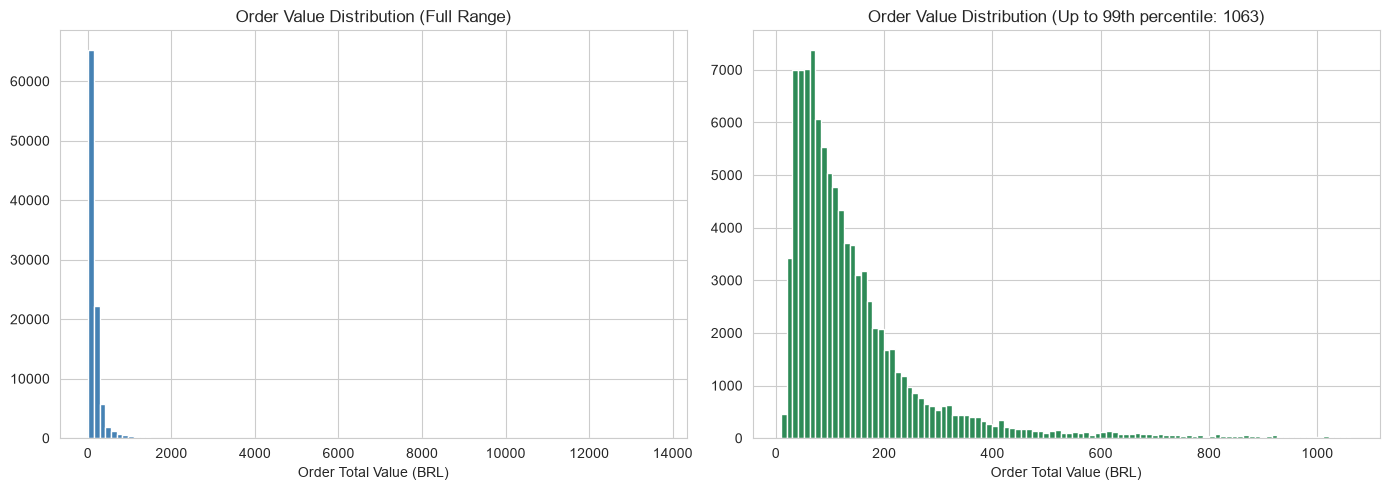

In [44]:
# Histogram — full range
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(aov_data, bins=100, color='steelblue', edgecolor='white')
axes[0].set_title('Order Value Distribution (Full Range)')
axes[0].set_xlabel('Order Total Value (BRL)')

# Histogram — zoomed (99th percentile tak, taaki extreme outliers chart na todein)
cutoff = aov_data.quantile(0.99)
axes[1].hist(aov_data[aov_data <= cutoff], bins=100, color='seagreen', edgecolor='white')
axes[1].set_title(f'Order Value Distribution (Up to 99th percentile: {cutoff:.0f})')
axes[1].set_xlabel('Order Total Value (BRL)')
plt.tight_layout()
plt.show()

In [45]:
# verification:extreme AOV orders - multiple/expensive items?
top_orders = fact_orders.nlargest(5, 'order_total_value')[['order_id', 'order_total_value', 'num_items']]
print(top_orders)

                               order_id  order_total_value  num_items
1451   03caa2c082116e1d31e67e9ae3700499           13664.08          8
44826  736e1922ae60d0d6a89247b851902527            7274.88          4
3150   0812eb902a67711a1cb742b3cdaa65ae            6929.31          1
99073  fefacc66af859508bf1a7934eab1e97f            6922.21          1
95184  f5136e38d1a14a4dbd87dff67da82701            6726.66          1


Category-wise Revenue Spread

In [1]:
# Category ke saath item-level revenue jodo
items_with_category = fact_order_items.merge(
    dim_product[['product_key', 'category_english']], on='product_key', how='left'
)

category_revenue = items_with_category.groupby('category_english').agg(
    total_revenue=('price', 'sum'),
    order_item_count=('order_id', 'count')
).reset_index().sort_values('total_revenue', ascending=False)

top_15 = category_revenue.head(15)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top_15['category_english'][::-1], top_15['total_revenue'][::-1], color='teal')
ax.set_title('Top 15 Categories by Revenue')
ax.set_xlabel('Total Revenue (BRL)')
plt.tight_layout()
plt.show()

print(top_15.to_string(index=False))
print(f"\nTop 15 categories revenue share: {top_15['total_revenue'].sum() / category_revenue['total_revenue'].sum() * 100:.1f}%")
print(f"Total categories: {len(category_revenue)}")

NameError: name 'fact_order_items' is not defined

Category level Pareto Analysis - Pareto chart (bar + cumulative line)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_3132\2584329099.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax1.set_xticklabels(top_20['category_english'], rotation=75, ha='right')


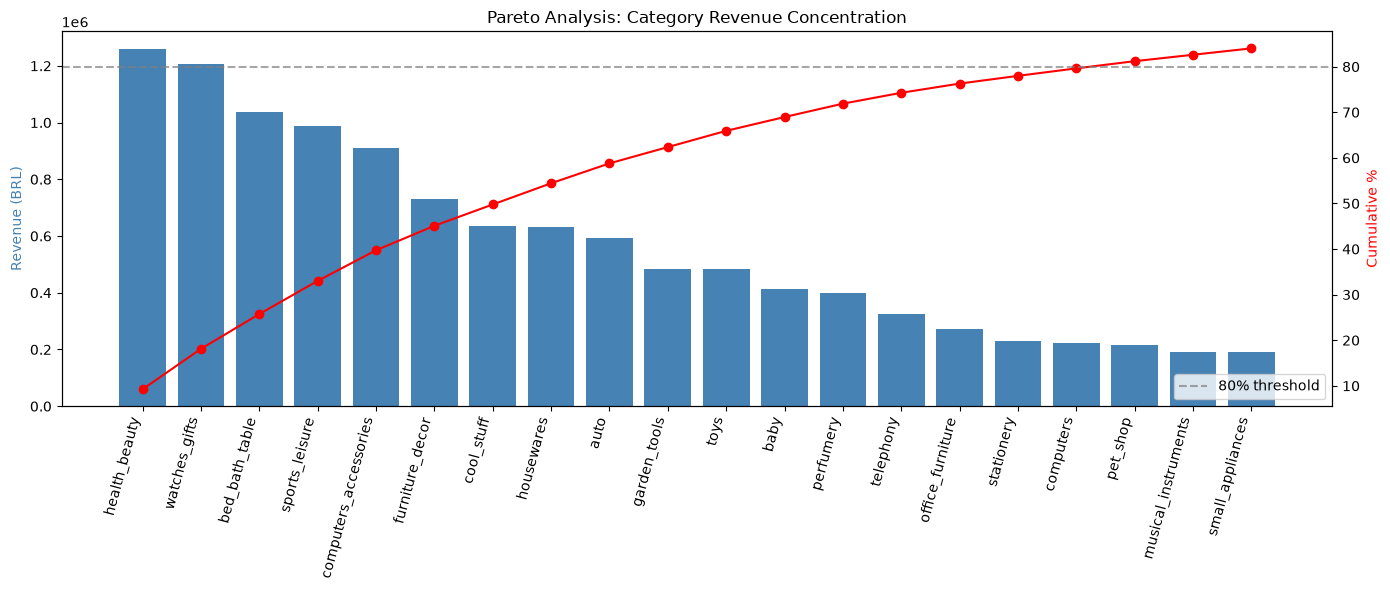

In [6]:
# SQL se result yahan load karo (ya seedha upar wali table se)
pareto_df = pd.read_sql("""
    WITH category_revenue AS (
        SELECT dp.category_english, SUM(foi.price) AS total_revenue
        FROM fact_order_items foi
        JOIN dim_product dp ON dp.product_key = foi.product_key
        GROUP BY dp.category_english
    )
    SELECT category_english, total_revenue,
        ROW_NUMBER() OVER (ORDER BY total_revenue DESC) AS category_rank,
        SUM(total_revenue) OVER (ORDER BY total_revenue DESC ROWS UNBOUNDED PRECEDING)
            * 100.0 / SUM(total_revenue) OVER () AS cumulative_pct
    FROM category_revenue
""", engine)

top_20 = pareto_df.head(20)

fig, ax1 = plt.subplots(figsize=(14, 6))
ax1.bar(top_20['category_english'], top_20['total_revenue'], color='steelblue')
ax1.set_ylabel('Revenue (BRL)', color='steelblue')
ax1.set_xticklabels(top_20['category_english'], rotation=75, ha='right')

ax2 = ax1.twinx()
ax2.plot(top_20['category_english'], top_20['cumulative_pct'], color='red', marker='o')
ax2.axhline(80, color='gray', linestyle='--', alpha=0.7, label='80% threshold')
ax2.set_ylabel('Cumulative %', color='red')
ax2.legend(loc='lower right')

plt.title('Pareto Analysis: Category Revenue Concentration')
plt.tight_layout()
plt.show()